In [1]:
import pandas as pd

In [3]:
import seaborn as sns

In [5]:
import matplotlib.pyplot as plt

In [7]:
import statsmodels.api as sm

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. dataset ya'ni analiz uchun tanlagan ma'lumotlarni yuklash. (analizdan oldin kaggledan yuklab olgan "creditcard.csv" faylini R Studioda kerakli variable va ma'lum bir muddatni tanlagan holda o'zgartirdim). Analiz uchun "daily_risk_audit.csv" va "daily_audit_results.csv" ma'lumotlaridan foydalandim. 

In [19]:
df_audit = pd.read_csv('daily_audit_results.csv')

In [29]:
#umumiy ma'lumotlarni ko'rish
df_risk

,Date,Transaction_Count,Fraud_Count,Total_Amount,Risk_Score,Z_Score,Is_Anomaly
0,2025-01-01,9159,16,818421.70,241.842170,-0.422014,Normal
1,2025-01-02,9655,24,886288.75,328.628875,-0.236691,Normal
2,2025-01-03,12338,15,1077588.38,257.758838,-0.388026,Normal
3,2025-01-04,10106,19,859113.36,275.911336,-0.349264,Normal
4,2025-01-05,10194,17,915195.53,261.519553,-0.379996,Normal
...,...,...,...,...,...,...,...
360,2025-12-27,9692,145,870501.42,1537.050142,2.343757,High Risk
361,2025-12-28,10977,165,960319.47,1746.031947,2.790014,High Risk
362,2025-12-29,10411,156,890097.01,1649.009701,2.582834,High Risk
363,2025-12-30,11537,173,1038568.03,1833.856803,2.977554,High Risk


In [31]:
df_audit

,Date,Fraud_Count,Total_Transactions,Risk_Score,Z_Score,Is_Anomaly,Operational_Errors,Fraud_Loss,OpEx_Loss,Total_LGD
0,2025-01-01,21,12208,222.208,0.925332,Normal,3,3150,1200,4350
1,2025-01-02,21,10988,220.988,0.899691,Normal,5,3150,2000,5150
2,2025-01-03,25,11785,261.785,1.757137,Normal,7,3750,2800,6550
3,2025-01-04,12,8848,128.848,-1.036851,Normal,3,1800,1200,3000
4,2025-01-05,23,10407,240.407,1.307827,Normal,6,3450,2400,5850
...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,14,8479,148.479,-0.624259,Normal,2,2100,800,2900
361,2025-12-28,18,10975,190.975,0.268896,Normal,3,2700,1200,3900
362,2025-12-29,15,9806,159.806,-0.386195,Normal,4,2250,1600,3850
363,2025-12-30,10,9122,109.122,-1.451440,Normal,5,1500,2000,3500


# 2. Foydalanayotgan ma'lumotlarimda bir xil variableslar qaytalanganligi uchun va ularni yaxlit datasetga birlashtiraman.  

In [49]:
# 'suffixes' yordamida takrorlangan ustunlarga '_remove' belgisini qo'ydim
master_df = pd.merge(df_risk, df_audit, on='Date', how='inner', suffixes=('', '_remove'))

In [51]:
# Takrorlangan (duplicate) ustunlarni avtomatik o'chirish uchun quidagi kodlardan foydalandim
# faqat birinchi jadvaldagi (df_risk) original ustunlarni qoldirdim
duplicate_cols = [col for col in master_df.columns if col.endswith('_remove')]


In [53]:
master_df.drop(columns=duplicate_cols, inplace=True)

In [55]:
print(f"Jami o'zgaruvchilar soni: {len(master_df.columns)}")

Jami o'zgaruvchilar soni: 12


In [59]:
print("Master Datasetimdagi o'zgaruvchilar")

Master Datasetimdagi o'zgaruvchilar


In [63]:
print(master_df.columns.tolist())

['Date', 'Transaction_Count', 'Fraud_Count', 'Total_Amount', 'Risk_Score', 'Z_Score', 'Is_Anomaly', 'Total_Transactions', 'Operational_Errors', 'Fraud_Loss', 'OpEx_Loss', 'Total_LGD']


In [630]:
#birlashtirilgan jadvalning umumiy ko'rinishi
master_df

,Sana,Tranzaksiyalar_Soni,Firibgarlik_Soni,Umumiy_Summa,Risk_Darajasi,Z_Indeksi,Anomaliya_Holati,Operatsion_Xatolar,Firibgarlik_Zarari,Operatsion_Zarar,...,Operatsion_Xatolar_Sq,Firibgarlik_Zarari_Sq,Operatsion_Zarar_Sq,Dam_Olish_Kuni_Sq,Kun_Monday,Kun_Saturday,Kun_Sunday,Kun_Thursday,Kun_Tuesday,Kun_Wednesday
0,2025-01-01,9159,16,818421.70,241.842170,-0.422014,Normal,3,3150,1200,...,9,9922500,1440000,0,False,False,False,False,False,True
1,2025-01-02,9655,24,886288.75,328.628875,-0.236691,Normal,5,3150,2000,...,25,9922500,4000000,0,False,False,False,True,False,False
2,2025-01-03,12338,15,1077588.38,257.758838,-0.388026,Normal,7,3750,2800,...,49,14062500,7840000,0,False,False,False,False,False,False
3,2025-01-04,10106,19,859113.36,275.911336,-0.349264,Normal,3,1800,1200,...,9,3240000,1440000,1,False,True,False,False,False,False
4,2025-01-05,10194,17,915195.53,261.519553,-0.379996,Normal,6,3450,2400,...,36,11902500,5760000,1,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,9692,145,870501.42,1537.050142,2.343757,High Risk,2,2100,800,...,4,4410000,640000,1,False,True,False,False,False,False
361,2025-12-28,10977,165,960319.47,1746.031947,2.790014,High Risk,3,2700,1200,...,9,7290000,1440000,1,False,False,True,False,False,False
362,2025-12-29,10411,156,890097.01,1649.009701,2.582834,High Risk,4,2250,1600,...,16,5062500,2560000,0,True,False,False,False,False,False
363,2025-12-30,11537,173,1038568.03,1833.856803,2.977554,High Risk,5,1500,2000,...,25,2250000,4000000,0,False,False,False,False,True,False


In [127]:

master_df['Sana'] = pd.to_datetime(master_df['Sana'])

# 3. Ma'lumotlarni tayyorlash va Feature Engineering ya'ni Kengaytirilgan yondashuv.
* modelning bashorat qilish aniqliligini oshirish maqsadida datasetga yangi variable lar qo'shaman. Risk darajasi haftaning qaysi kunlarida yuqoriroq bo'lishini tekshirish uchun 'dam_olish_kuni' o'zgaruvchisini qo'shmoqchiman. 

In [129]:
#  Hafta kunini hisoblash 
master_df['Hafta_Kuni'] = master_df['Sana'].dt.dayofweek

In [131]:
# Dam olish kunini aniqlash (Shanba/Yakshanba bo'lsa 1, aks holda 0)
master_df['Dam_Olish_Kuni'] = master_df['Hafta_Kuni'].apply(lambda x: 1 if x >= 5 else 0)

In [133]:
# "Tizim Yuklamasi Og'irligi" deb nomlangan yangi variable qo'shdim, va bundan maqsad har bir tranzaksiyaga to'g'ri keladigan IT xatolar ulushini ko'rish
master_df['Tizim_Yuklamasi_Og_irligi'] = master_df['Operatsion_Xatolar'] / master_df['Tranzaksiyalar_Soni']

In [135]:
# Har 1000 ta tranzaksiyaga to'g'ri keladigan firibgarlik sonini ko'rish uchun " Firibgarlik Zichligi " o'zgaruvchisini qo'shdim
master_df['Firibgarlik_Zichligi'] = (master_df['Firibgarlik_Soni'] / master_df['Tranzaksiyalar_Soni']) * 1000

In [137]:
master_df

,Sana,Tranzaksiyalar_Soni,Firibgarlik_Soni,Umumiy_Summa,Risk_Darajasi,Z_Indeksi,Anomaliya_Holati,Operatsion_Xatolar,Firibgarlik_Zarari,Operatsion_Zarar,Umumiy_Yoqotish,Tizim_Yuklamasi_Og_irligi,Firibgarlik_Zichligi,Hafta_Kuni,Dam_Olish_Kuni
0,2025-01-01,9159,16,818421.70,241.842170,-0.422014,Normal,3,3150,1200,4350,0.000328,1.746916,2,0
1,2025-01-02,9655,24,886288.75,328.628875,-0.236691,Normal,5,3150,2000,5150,0.000518,2.485759,3,0
2,2025-01-03,12338,15,1077588.38,257.758838,-0.388026,Normal,7,3750,2800,6550,0.000567,1.215756,4,0
3,2025-01-04,10106,19,859113.36,275.911336,-0.349264,Normal,3,1800,1200,3000,0.000297,1.880071,5,1
4,2025-01-05,10194,17,915195.53,261.519553,-0.379996,Normal,6,3450,2400,5850,0.000589,1.667648,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,2025-12-27,9692,145,870501.42,1537.050142,2.343757,High Risk,2,2100,800,2900,0.000206,14.960792,5,1
361,2025-12-28,10977,165,960319.47,1746.031947,2.790014,High Risk,3,2700,1200,3900,0.000273,15.031429,6,1
362,2025-12-29,10411,156,890097.01,1649.009701,2.582834,High Risk,4,2250,1600,3850,0.000384,14.984151,0,0
363,2025-12-30,11537,173,1038568.03,1833.856803,2.977554,High Risk,5,1500,2000,3500,0.000433,14.995233,1,0


In [140]:

import seaborn as sns

# 4. Datasetlarni birlashtirib, kerakli variable larni qo'shdim. Endi qaysi o'zgaruvchilar bir-biriga eng kuchli ta'sir qilishini aniqlamoqchiman. Ya'ni 'Tizim_Yuklamasi_Og_irligi' oshganda 'Risk_Darajasi' ham oshishini raqamlarda ko'rish maqsadida korrelatsiya tahliliga o'taman.

In [142]:
import matplotlib.pyplot as plt

In [144]:
# Faqat raqamli ustunlarni tanladim
numeric_df = master_df.select_dtypes(include=['float64', 'int64'])

In [146]:
plt.figure(figsize=(12, 10))

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

<Axes: >

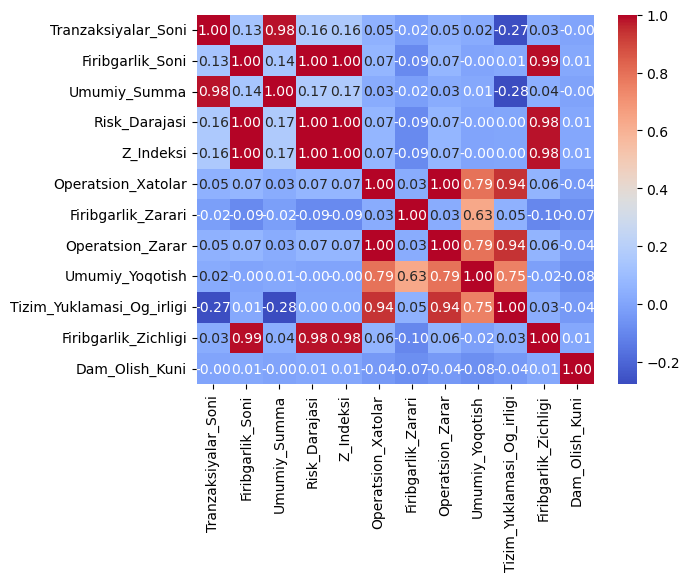

In [148]:
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

In [162]:
extended_vars = ['Tranzaksiyalar_Soni', 'Firibgarlik_Soni', 'Umumiy_Summa', 
    'Operatsion_Xatolar', 'Firibgarlik_Zarari', 'Operatsion_Zarar', 
    'Umumiy_Yoqotish', 'Tizim_Yuklamasi_Og_irligi', 'Firibgarlik_Zichligi', 'Dam_Olish_Kuni']

# 5.Barcha o'zgaruvchilar orasida chiziqli bog'liqlikni ko'rib chiqmoqchiman va potensial multikolliniarlikni vizual aniqlash uchun scatterplotdan foydalanaman.
* "Risk_Darajasi"ni modelning "Target" (Y) o'zgaruvchisi sifatida belgiladim.
* Bu bosqichda 'extended_vars' (kengaytirilgan ro'yxat) dan foydalanishimning maqsadi, nafaqat risk sabablarini (Explanatory Variables), balki uning oqibatlarini (Impact Factors) ham yaxlit manzara ko'rinishida o'rganish.
* Hafta kunlari diskret (categorical) o'zgaruvchi bo'lgani uchun ularni scatterplotga qo'shmadim,'Dam_Olish_Kuni' dummy o'zgaruvchisi sifatida Boxplot orqali tahlil qilaman.

In [164]:
y_var = 'Risk_Darajasi'

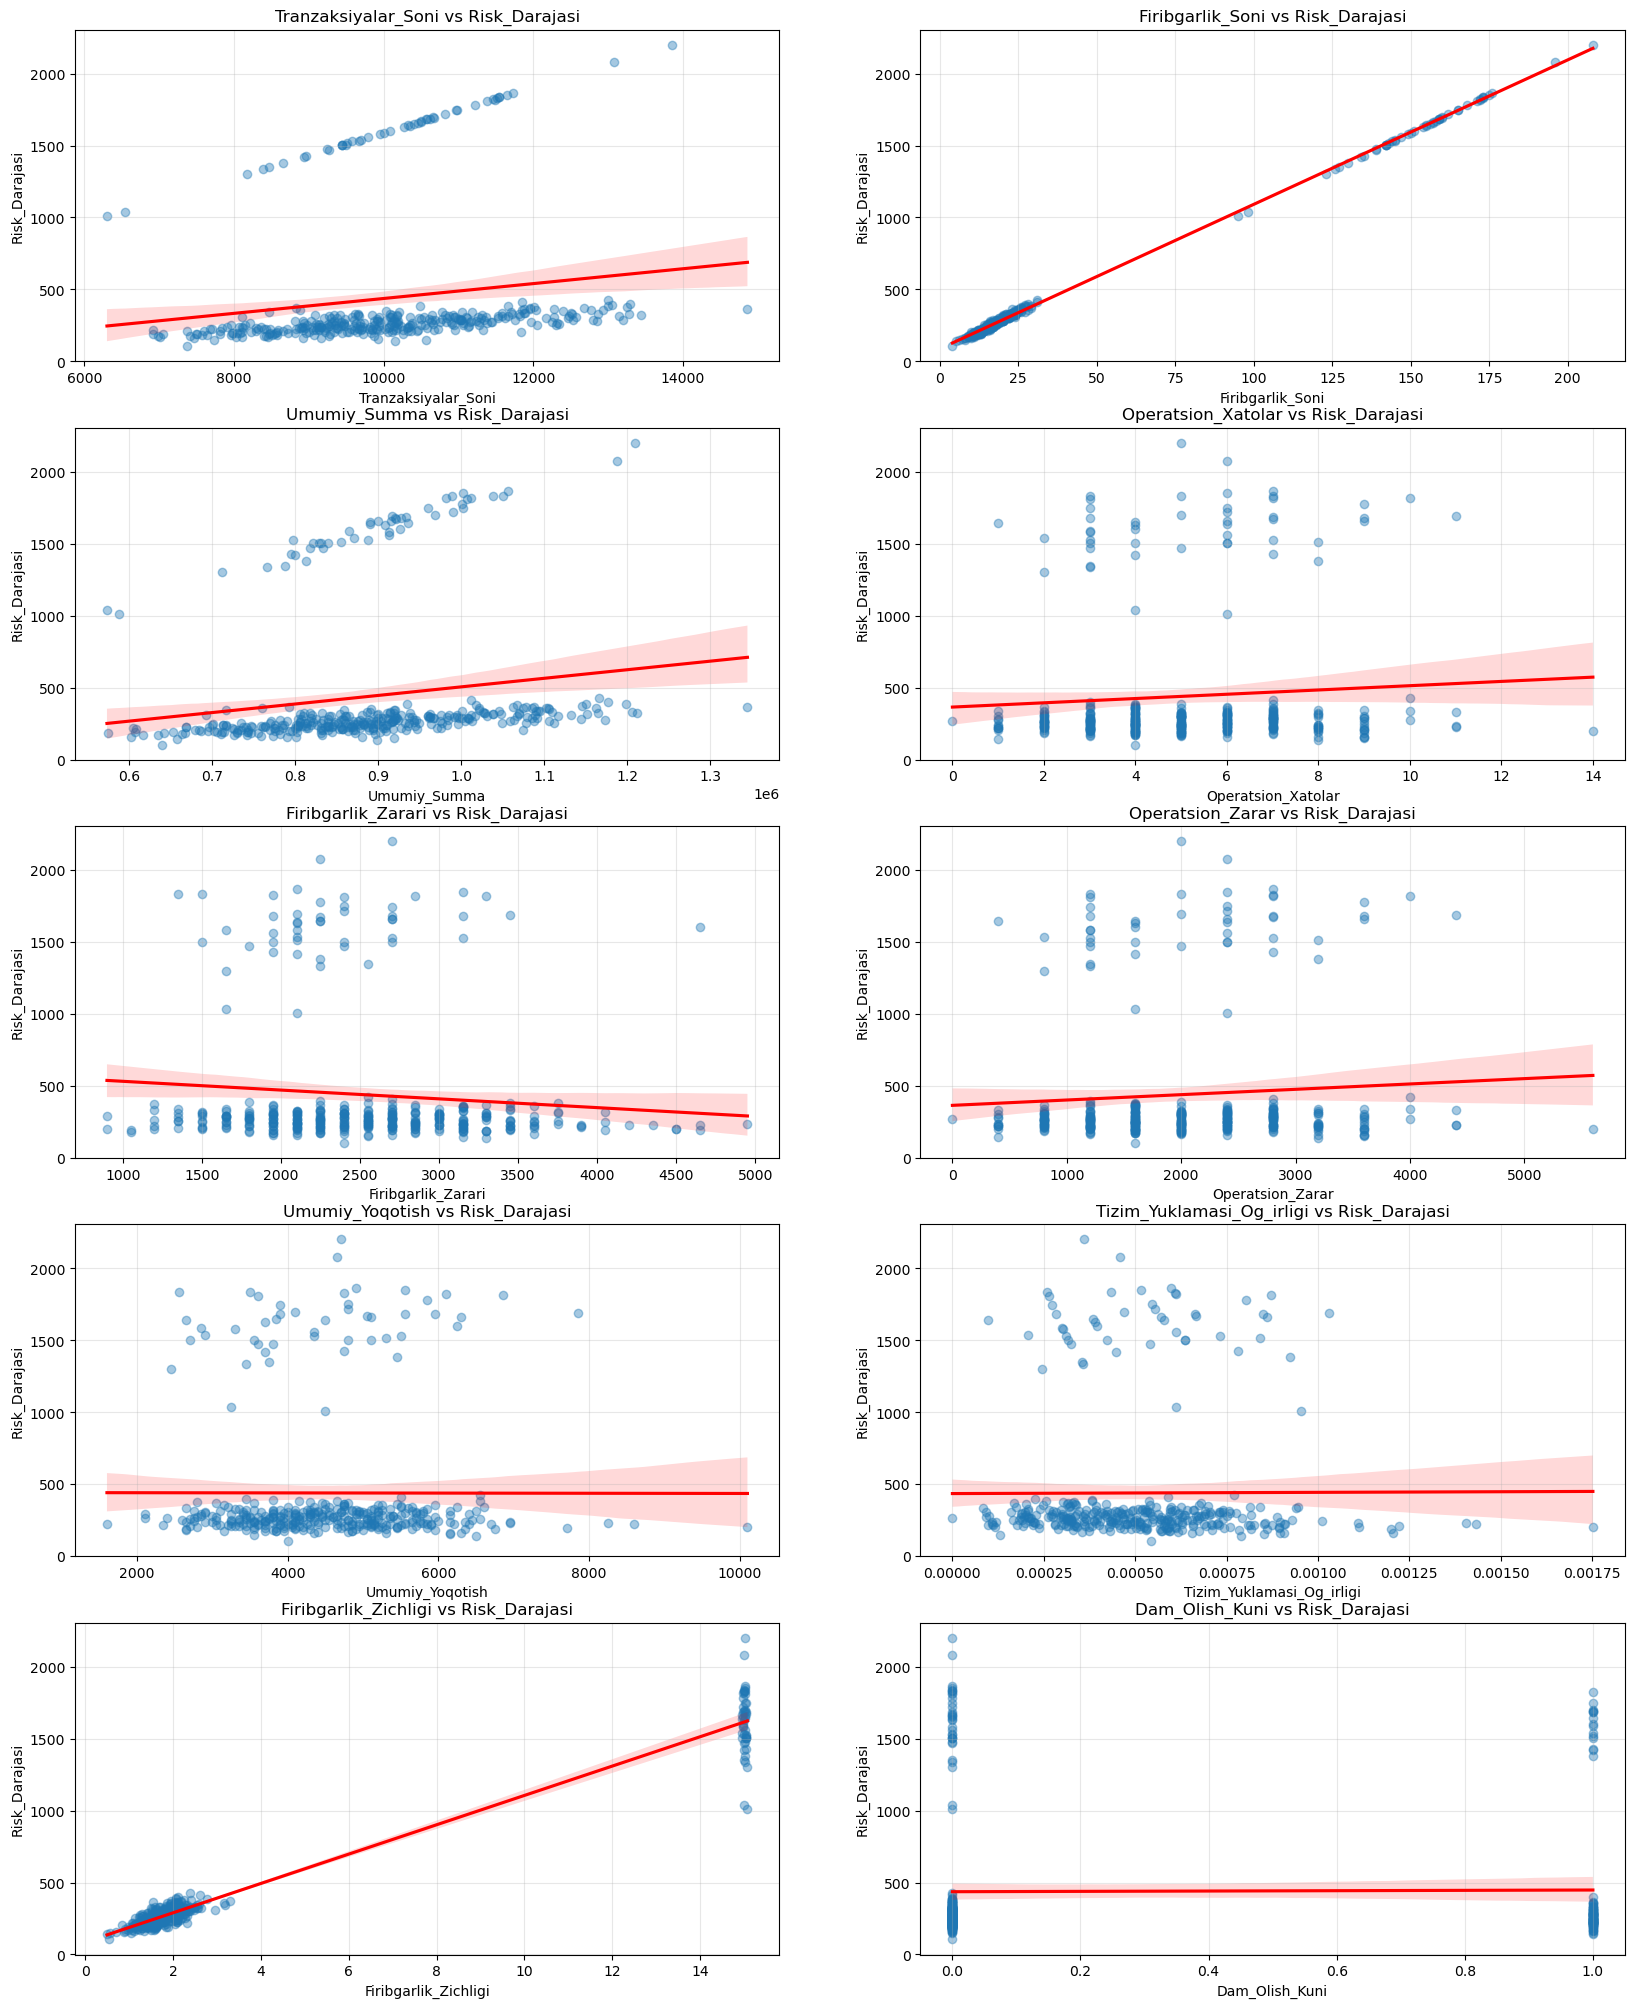

In [166]:
plt.figure(figsize=(20, 25))
for i, var in enumerate(extended_vars):
    plt.subplot(5, 2, i+1)
    sns.regplot(x=var, y='Risk_Darajasi', data=master_df, scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
    plt.title(f'{var} vs Risk_Darajasi')
    plt.grid(True, alpha=0.3)

# Scatterplot tahlili
1. Scatterplotga ko'ra Firibgarli_Zichligi va Firibgarlik_Soni bilan Risk _Darajasi o'rtasida kuchli chiziqli regressiya borligini ko'rsatyapti. 
2. Operatsion_Xatolar, Operatsion_Zarar, Firibgarlik_Zarari va Dam_Olish_Kuni bilan risk darajasi o'rtasida kvvadratik bog'liqlik ko'rinyapti. Ushbu avriable lar uchun  "Tansformation" metodini qo'llab ko'rmoqchiman, chunki kvadratik regressiya positive yoki negative bo'lishi mumkin. Bank risklari ko'pincha "progressiv" xarakterga ega. Ya'ni, faktorlarning ma'lum bir nuqtagacha oshishi riskni sekin o'stiradi, lekin ma'lum bir "tanqidiy nuqta" dan o'tgandan keyin risk darajasi keskin tushadi. yoki aksi.
3. Tranzaksiyalar_Soni, Umumiy_Yo'qotish va Tizim_Yuklamasi_Og'irligi bilan Risk_Darajasi o'rtasida kuchsiz chiiziqli bog'liqlik bo'lishi mumkin. va yuqorida yana bir guruh ajralib nuqtalar turibdi, ular umumiy trenddan uzoqda joylashgan. Ushbu outlierlar (anomal nuqtalar) risk darajasi yo'qotish hajmidan qat'iy nazar,ba'zi kunlarda keskin oshib ketishini ko'rsatadi. Ular xatolik, yani "data entry error" yoki haqiqiy extremal voqea ya'ni bank tizimidagi anomal holatlar yoki ekstremal risk kunlari bo'lishi mumkin. Bu kunlar modelning chiziqliligini buzayotgani sababli, ularni alohida ekstremal voqealar sifatida tahlil qilaman. 



In [221]:
from scipy import stats

# 6. Outlierlarni tekshiraman, agar bu nuqtalar xatolik bo'lsa ularni o'chirib yuboraman, sababi, bu nuqtalar regressiya chizig'iga kuchli ta'sir o'tkazmoqda (high leverage). Agar ular inobatga olinmasa, model o'rtacha kunlik riskni aniqroq bashorat qiladi.
* Modelni qurishdan avval ma'lumotlar sifatini tekshirishda outlier test qilish muhim . 
* Z-score metodi yordamida 'Risk_Darajasi'dagi ekstremal outlierlarni aniqlayman. 
* Bu qadam transformation va regressiya natijalarining xolis bo'lishini ta'minlaydi.

In [223]:
import numpy as np

In [225]:
# Risk_Darajasi uchun Z-score hisoblayman
z_scores = np.abs(stats.zscore(master_df['Risk_Darajasi']))

In [227]:
# Threshold (chegara) sifatida 3 ni belgilayman (99.7% ma'lumotlar ichida bo'lishi kerak)
threshold = 3

In [229]:
outliers = master_df[z_scores > threshold]

In [231]:
print(f"Aniqlangan jami outlierlar soni: {len(outliers)}")

Aniqlangan jami outlierlar soni: 4


In [235]:
# Outlierlarni vizual ko'rish uchun display qilaman
if len(outliers) > 0:
    print("\n--- Eng ekstremal outlierlar ro'yxati ---")
    display(outliers[['Sana', 'Risk_Darajasi', 'Firibgarlik_Zichligi', 'Umumiy_Yoqotish']].sort_values(by='Risk_Darajasi', ascending=False))
else:
    print("Ekstremal outlierlar aniqlanmadi.")


--- Eng ekstremal outlierlar ro'yxati ---


,Sana,Risk_Darajasi,Firibgarlik_Zichligi,Umumiy_Yoqotish
359,2025-12-26,2200.980033,15.010464,4700
69,2025-03-11,2078.774869,14.990440,4650
89,2025-03-31,1865.627659,15.013222,4900
86,2025-03-28,1850.185595,15.027909,5550


**Xulosalarim:**
1. Firibgarlik_Zichligi ko'rsatkichi -15 birlikka yetganida, bankning risk darajasi o'rtacha trenddan 4-5 barobar ko'proq.
2. 2025-yilning mart oyining oxiri (26, 28, 31-mart) bank uchun eng og'ir operatsion davr bo'lganligini aniqladim. Taxminimcha bu kunlar aynan 2025-yilning    "Ramazon" va "Hayit" bayramlari , shuningdek "Yangi yil" kunlari bo'lgan, va mantiqan, ushbu kunlarda o'tkazmalar odatdagidan yuqori bo'lgan bo'lishi mumkin. Shu mantiqqa asoslanib ularni tizim xatosi emas, haqiqiy extremal voqea bo'lishi mumkin degan xulosaga keldim.
3. Outlierlarni o'chirib yuborsam bamkdagi eng ektremal tranzaksiya kunlari haqidagi ma'lumotni yo'qotishim mumkin. Outlierlarni butunlay o‘chirib yuborish o‘rniga keyingi bosqichda ularning ta'sirini yumshatish (weighting) yoki transformation metodini qo'llashga qaror qildim. Chunki ushbu nuqtalar modelning chiziqliligini buzadi. 



# 7. Multikolliniarlik (VIF) Tahlili
* Modelga kiritilayotgan mustaqil o'zgaruvchilar o'rtasida o'ta yuqori bog'liqlik yo'qligini tekshirish.
* barcha 10 ta o'zgaruvchini VIF ga kiritmadim, chunki ayrimlari bir-birining tarkibiy qismi yoki hisoblangan hosilalari, masalan, 'Operatsion Zarar',bu 'Umumiy Yo'qotish' tarkibiga kiradi. Multikolliniarlikning oldini olish uchun faqat bir-biriga matematik bog'liq bo'lmagan, eng muhim mustaqil faktorlarni (independent variables) tanlab oldim.

In [246]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [248]:
#  VIF tekshiruvi uchun o'zgaruvchilarni faqat original ko'rinishdagi variable larni tanladim.
vif_features = [
    'Firibgarlik_Zichligi', 
    'Tranzaksiyalar_Soni', 
    'Umumiy_Yoqotish', 
    'Tizim_Yuklamasi_Og_irligi', 
    'Dam_Olish_Kuni']

In [250]:
# Ma'lumotlarni tayyorlash
X_vif = master_df[vif_features].dropna()

In [252]:
# Konstanta ya'ni intercept qo'shaman, busiz R square noto'g'ri hisoblanadi va VIF ko'rsatkichlari to'g'ri chiqmaydi.
X_vif = sm.add_constant(X_vif) 

In [254]:
# VIF koeffitsientlarini hisoblash
vif_df = pd.DataFrame()

In [256]:
vif_df["Faktor"] = X_vif.columns

In [258]:
vif_df["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

In [260]:
print("--- VIF TEST NATIJALARI ---")

--- VIF TEST NATIJALARI ---


In [262]:
display(vif_df.sort_values(by="VIF", ascending=False))

,Faktor,VIF
0,const,67.743920
4,Tizim_Yuklamasi_Og_irligi,2.892248
3,Umumiy_Yoqotish,2.691530
2,Tranzaksiyalar_Soni,1.241922
1,Firibgarlik_Zichligi,1.010580
5,Dam_Olish_Kuni,1.006540


# VIF Testi Natijalari va Interpretatsiya

* VIF testi natijalari barcha tanlangan mustaqil o'zgaruvchilar o'rtasida **multikolliniarlik muammosi mavjud emasligini** ko'rsatdi. 

1.  Barcha predictorlar uchun VIF ko'rsatkichi **5 dan sezilarli darajada past** ,maksimal 2.89. Bu modelning koeffitsientlari barqaror ekanligini va har bir faktor risk darajasiga o'zining alohida, xolis ta'sirini ko'rsata olishini anglatadi.
2. Hisoblangan ustunlarni (masalan, Operatsion_Zarar yoki Firibgarlik_Soni) chiqarib tashlaganim o'z samarasini berdi.Modelda ortiqcha takrorlanish (redundancy) bartaraf etildi.
3. Ushbu "toza" o'zgaruvchilar bilan yakuniy **Weighted Least Squares (WLS)** va **Square Transformation** modelini qurishga o'taman.

# 8. Outlier ko'rsatgan o'zgarishlar uchun 'WLS' transformation va kvadratik regressiya kabi ko'ringan o'zgarishlar uchun 'Square" transformation qo'llagan holda model tuzaman

In [239]:
import statsmodels.api as sm

In [264]:
# SQUARE TRANSFORMATION (Kvadratga oshirish). 
#Scatterplot bergan natijalarga ko'ra kvadratik bog'liqlik bor deb hisoblagan o'zgarishlar uchun " square transformation" qo'lladim. 
# Ushbu faktorlarning riskka ta'siri eksponental bo'lishi mumkinligini hisobga olgan holda. 
master_df['Operatsion_Xatolar_Sq'] = master_df['Operatsion_Xatolar']**2
master_df['Firibgarlik_Zarari_Sq'] = master_df['Firibgarlik_Zarari']**2
master_df['Operatsion_Zarar_Sq'] = master_df['Operatsion_Zarar']**2

In [266]:
# WEIGHTED TRANSFORMATION (Weights)
# Tranzaksiyalar soni, umumiy yo'qotish va tizim yuklamasidagi outlierlar ta'sirini 
# kamaytirish uchun Risk_Darajasi qoldiqlariga asoslangan vaznlar hisoblayman. 
z_scores = np.abs((master_df['Risk_Darajasi'] - master_df['Risk_Darajasi'].mean()) / master_df['Risk_Darajasi'].std())
weights = 1.0 / (z_scores + 1e-5)

In [286]:
#  FINAL FEATURES (Model tarkibi)
final_x_features = [
    'Firibgarlik_Zichligi',
    'Tranzaksiyalar_Soni',
    'Umumiy_Yoqotish',
    'Tizim_Yuklamasi_Og_irligi',
    
    # Square va Original birga kiritiladi:
    'Operatsion_Xatolar', 'Operatsion_Xatolar_Sq',
    'Firibgarlik_Zarari', 'Firibgarlik_Zarari_Sq',
    'Operatsion_Zarar', 'Operatsion_Zarar_Sq',
    
    'Dam_Olish_Kuni' # Dummy
]

In [288]:
X_final = master_df[final_x_features]

In [290]:
X_final = sm.add_constant(X_final)

In [292]:
Y = master_df['Risk_Darajasi']

In [298]:
#  YAKUNIY WLS MODEL
master_model = sm.WLS(Y, X_final, weights=weights).fit()

In [300]:
print(master_model.summary())

                            WLS Regression Results                            
Dep. Variable:          Risk_Darajasi   R-squared:                       0.979
Model:                            WLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     2107.
Date:                Wed, 06 May 2026   Prob (F-statistic):          1.36e-294
Time:                        22:18:25   Log-Likelihood:                -1772.9
No. Observations:                 365   AIC:                             3564.
Df Residuals:                     356   BIC:                             3599.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

# MODEL TAHLILI (WLS + Square tranformation) 

* Ushbu modelda Outlier ko'rsatgan variable lar uchun 'WLS' transformatsiya va kvadratik regression bo'lishi mumkin hisoblangan variable lar uchun 'Square' transformatsiya metodlarini qo'lladim.
  
# Modelning umumiy aniqlik darajasi quidagi natijani ko'rsatdi:
*   * R-squared (0.979), model bankdagi risk darajasi o'zgarishining **97.9%** qismini tushuntirib bera olishini ifodalaydi. Bu tanlangan faktorlarning o'ta yuqori bashorat qilish qobiliyatiga ega ekanligini anglatadi.
*   *Prob (F-statistic) [1.36e-294]*, ya'ni ko'rsatkichning nolga yaqinligi modelning tasodifiy emasligini va statistik jihatdan ahamiyatli (significant) ekanligini tasdiqlaydi.
  
# Kvadratik Transformatsiya va Parabola Tahlili
Risk omillarining chiziqli bo'lmagan (non-linear) ta'sirini o'rganish orqali quyidagi muhim xulosalar olindi:

* A. Operatsion Xatolar (Kritik Faktor)*
  *Koeffitsientlar:* `Operatsion_Xatolar` (musbat) va `Operatsion_Xatolar_Sq` (musbat, $P=0.024$). Parabola shoxlari yuqoriga qaragan ($a > 0$). Bu shuni anglatadiki, operatsion xatolar soni oshgani sayin, risk darajasi **kvadratik sur’atda tezlashib** o‘sadi.  Xatolar soni ma'lum bir kritik nuqtadan o'tsa, risk "portlash" xavfiga ega. Bu tizim yuklamasini nazorat qilish bank xavfsizligi uchun eng ustuvor vazifa ekanligini ko'rsatadi.
  
* B. Firibgarlik Zarari (Chiziqli Trend)*
P-value (0.745), ya'ni `Firibgarlik_Zarari_Sq` ko‘rsatkichi statistik jihatdan ahamiyatsiz chiqdi.Bu firibgarlik zararining riskka ta’siri kvadratik emas, balki chiziqli (linear) ekanligi anglatadi.

# Muhim va Ahamiyatsiz Faktorlar
*   **Firibgarlik_Zichligi (t = 126.5, P=0.000)** Bu modelning eng kuchli prediktori. Uning ta'siri shunchalik yuqoriki, summary natijalaridan bankdagi risk darajasini belgilovchi asosiy drayver aynan shu o'zgaruvchi ekanligi ko'rinyapti. 
*   **Umumiy_Yoqotish (P=0.367)** Qiziqarli natijalardan biri umumiy yo'qotish 'not significant' p-value ko'rsatdi, ya'ni yo'qotilgan pul miqdoridan ko'ra, operatsion yuklama va firibgarlik zichligi risk uchun muhimroq ekan.

# MODELNI OPTIMALLASHTIRISH REJASI

Summary izoh qilishiga ko'ra **"Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 4.16e-28. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular."** Ya'ni modelda multikolinearlik baland. Chunki modelga parabola negativ yoki positiv o'sishini aniqlash maqsadida kvadratratik regressiya bor bo'lishi mumkin hisoblangan o'zgarishlarning ham x ni, ham x 
2ni kiritgandim.

* Modeldagi multikolliniarlikni kamaytirish va uni yanada soddaroq holatga keltirish uchun quyidagi qadamlarni rejalashtirdim:

1. **'Dam_Olish_Kuni'** o'zgaruvchisini har bir hafta kunlari uchun boxplotda tekshiraman. Agar boxplotda har bir hafta kuni turlicha natija ko'rsatsa, hafta kunlarini 'dummy' sifatida modelga qo'shaman. Agar risk barcha kunlarda barqaror ketsa, ushbu o'zgarishlarni 'dummy' shaklda modelga qo'shishning hojati yo'q. 
2.   **Ahamiyatsiz kvadratlarni chiqarish:** Statistika jihatdan ahamiyatsiz ($P > 0.05$) bo'lgan `Firibgarlik_Zarari_Sq` va `Operatsion_Zarar_Sq` a'zolarini modeldan olib tashlayman.
3.  **Faqat "Ishlaydigan" o'zgaruvchilarni qoldirish:** Faqat `Operatsion_Xatolar_Sq` va chiziqli asosiy faktorlarni qoldirib, modelning tushunarlilik darajasini oshiraman.

# 10. BOXPLOT HOSIL QILISH


/var/folders/s5/hs766b9x1sj0fcxd6ztx9lv00000gn/T/ipykernel_30211/1328007075.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hafta_Kuni', y='Risk_Darajasi', data=master_df,


<Axes: xlabel='Hafta_Kuni', ylabel='Risk_Darajasi'>

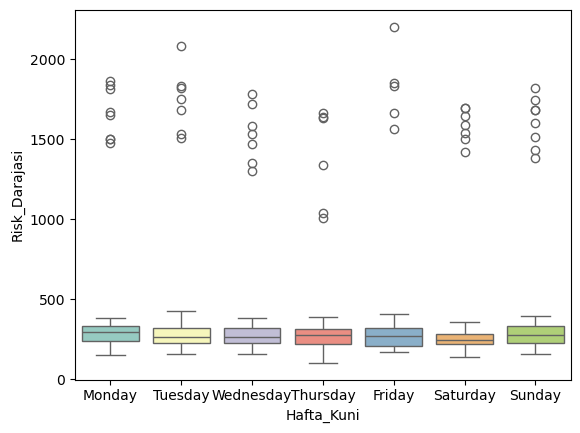

In [309]:
sns.boxplot(x='Hafta_Kuni', y='Risk_Darajasi', data=master_df, 
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            palette='Set3')

# BOXPLOT TAHLILI
* Grafikda haftaning barcha kunlari uchun Risk Darajasi deyarli bir xil taqsimlangan.
* Barcha kunlar uchun deyarli bir xil median chiziqlar gorizontal darajada turibdi. Bu degani, haftaning qaysi kuni bo'lishidan qat'iy nazar, o'rtacha risk o'zgarmaydi. Qutilar balandligi ham barcha kunlarda o'xshash.

# Risk barcha hafta kunlarida bir xil barqarorlikni ko'rsatgani uchun, va sezilarli farq ko'rinmagani uchun, modelni murakkablashtirmaslik va multikolliniarlikdan qochish maqsadida, hafta kunlarini alohida dummy o'zgaruvchi sifatida kiritmaslikka qaror qildim.

# 11. YANGI MODELNI QURISH

In [492]:
# Faqat mavjud ustunlarni tanlab oldim
X = master_df[[f for f in selected_features if f in master_df.columns]]

In [494]:
X = sm.add_constant(X)

In [496]:
Y = master_df['Risk_Darajasi']

In [498]:
# Vaznlarni outlierlar ta'sirini kamaytirish uchun hisobladim
z_scores = np.abs((Y - Y.mean()) / Y.std())

In [500]:
weights = 1.0 / (z_scores + 1e-5)

In [502]:
# Faqat ishlaydigan kvadratni qoldiraman
# Faqat 'Operatsion_Xatolar_Sq' qoladi
if 'Operatsion_Xatolar' in master_df.columns:
    master_df['Operatsion_Xatolar_Sq'] = master_df['Operatsion_Xatolar']**2

In [506]:
# 3. OPTIMALLASHTIRILGAN FEATURELARNI TANLASH
# Ahamiyatsiz kvadratlar (Firibgarlik_Zarari_Sq va Operatsion_Zarar_Sq) olib tashlandi
selected_features = [
    'Firibgarlik_Zichligi',        # Chiziqli
    'Tranzaksiyalar_Soni',         # Chiziqli
    'Tizim_Yuklamasi_Og_irligi',   # Chiziqli
    'Umumiy_Yoqotish',             # Chiziqli
    'Operatsion_Xatolar',          # Chiziqli (Original)
    'Operatsion_Xatolar_Sq'        # Kvadratik (Ishlaydigan)
]

In [508]:
# Weighted Least Squares modelini ishga tushirish
optimized_model = sm.WLS(Y, X, weights=weights).fit()

In [510]:
# 5. NATIJALARNI KO'RISH
print(" OPTIMALLASHTIRILGAN MODEL SUMMARY ")

 OPTIMALLASHTIRILGAN MODEL SUMMARY 


In [512]:
print(optimized_model.summary())

                            WLS Regression Results                            
Dep. Variable:          Risk_Darajasi   R-squared:                       0.979
Model:                            WLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     2823.
Date:                Thu, 07 May 2026   Prob (F-statistic):          5.57e-298
Time:                        15:17:00   Log-Likelihood:                -1773.1
No. Observations:                 365   AIC:                             3560.
Df Residuals:                     358   BIC:                             3587.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

# YANGI MODEL TAHLILI (SUMMARY)

* Natijalarga ko'rsa eng kuchli faktor **'Firibgarlik Zichligi',98.8340**. Agar firibgarlik zichligi 1 birlikka oshsa, masalan, har 1000 ta tranzaksiyadan bittasi ko'p fraud bo'lsa, umumiy risk darajasi 99 birlikka keskin sakraydi. Firibgarlik holati shunchaki pul yo'qotish emas. Birgina firibgarlik operatsiyasi bankning obro'siga, mijozlar ishonchiga va audit tekshiruvlariga sabab bo'ladi. Agar zichlik oshsa,firibgarlar tizimdagi teshikni topib olishgan bo'lishi mumkin. Bu bitta tasodifiy xato emas, balki hujumning "zichlashganini" bildiradi. Mantiqan oladigan bo'lsak, bankda 1 kunda 100,000 ta tranzaksiya o'tadi deylik, shulardan 5 tasi firibgarlik, bunda zichlik juda past bo'ladi. Modelimdagi "kritik" holatda esa, 100,000 tadan 105 tasi firibgarlik, ya'ni 'firibgarlik_zichligi ' o'zgaruvchisining 1 birlik o'sishi, riskni 99 barobar oshirib yuboryapti. Xulosa qilib aytadigan bo'lsam, modeldagi holatda bank monitoring bo'limi barcha resurslarni firibgarlik zichligini kamaytirishga qaratishi kerak, chunki bu faktor qolgan barcha operatsion yo'qotishlardan ko'ra ko'proq xavf tug'diryapti.

* **Tranzaksiyalar Soni 0.0033** ni ko'rsatdi.	Ya'ni hajm faktori sifatida har bir yangi tranzaksiya o'zi bilan kichik (0.0033) risk olib keladi. Menimcha bu normal holat, sababi ko'p pul aylangan joyda ehtimoliy risk ham tabiiy ravishda oshaveradi.

* **Umumiy Yo'qotish- 0.0019** moliyaviy zararning nisbiy vazni. Ushbu koeffitsientning pastligi bankning moliyaviy barqarorligidan dalolat beradi. Bu bank uchun pul yo'qotishdan ko'ra, jarayonlarning buzilishi xavfliroq ekanini isbotlaydi. Bank o'z kapitali bilan bu zararlarni qoplashi mumkin, lekin operatsion tizimning teshiklari bankning barqarorligiga o'nlab marta kuchliroq zarba beradi. Masalan, bank kassa amaliyotida xatolik tufayli $1000 yo'qotdi. Modelga ko'ra, bu riskni deyarli o'zgartirmaydi. Biroq, agar shu $1000 tizimli firibgarlik yoki takroriy operatsion xato natijasida yo'qolsa, risk bir necha barobar oshadi.

* Model natijalariga ko‘ra, **Operatsion_Xatolar_Sq** (kvadratik slope) koeffitsienti riskning chiziqli emas, balki kvadratik sur’atda  ijobiy U-shaklida o‘sishini ko‘rsatdi. Kvadratik o'zgaruvchi-0.1954, Chiziqli o'zgaruvchi- 5.3818. 
Agar xatolar soni 10 tadan 20 taga chiqsa, risk 2 marta emas, balki kvadratik sur'atda, ya'ni 4 marta tezlashib o'sadi. Xatolarning to'planishi bank tizimini "portlash" holatiga olib keladi.  Bu shuni anglatadiki, bank tizimi ma'lum bir yuklamagacha barqaror ishlaydi, lekin xatolar soni kritik nuqtadan o'tgach, risk effekti kabi nazoratdan chiqib ketadi. 
 
# Root cause Analysis- Ildiz sabablar tahlili
Bankda operatsion xatolar nima uchun chiziqli emas, balki kvadratik o'sib ketadi? 
* Inson omili , ya'ni ish hajmi oshishi bilan xodimlar charchaydi va diqqat pasayadi. Yoki tizimlar tufayli bo'lishi mumkin. Serverlar yuklamasi oshganda masalan, bayramlarda, javob qaytarish vaqti cho'ziladi, bu esa tranzaksiyalarning sekinlashishi qolishiga va xatolarga sabab bo'ladi. Shuningdek, ko'p sonli tranzaksiyalarni bir vaqtda qayta ishlashda yuzaga kelishi mumkin.
  
# Fikrlarim
* Albatta bu sun'iy dataset yordamida o'tkazgan tahlilim. Haqiqiy dataet bilan tuzilgan modellar ham vaqt o'tishi bilan eskiradi.
Firibgarlar o'z usullarini doim o'zgartirib turishadi. Shuning uchun, ushbu modelni har oy yangi ma'lumotlar bilan qayta o'qitish va uning aniqligini R-squaredni tekshirgan holda nazorat qilib borish shart. Agar aniqlik 90% dan pastga tushsa, yangi faktorlarni , masalan, kiber-hujumlar soni kabi variable larni kiritish yanada aniq natijalarni beradi.
* Loyiha davomida outlierlar bilan ishlashda shu fikrga keldim, bankda ma'lumotlar yig'ish tizimi ba'zan nosimmetrik ishlashi mumkin. Kelajakda modelni yanada kuchaytirish uchun har bir tranzaksiya turi ,onlayn, ATM, terminal bo'yicha alohida tahlil o'tkazishni rejalashtiryapman. Chunki, odatda, onlayn tranzaksiyalar yuqori firibgarlik zichligi va texnik xatolarga moyil, ATM va Terminallar esa ko'proq jismoniy va operatsion xatolarga masalan, kesh-inkassatsiya yoki apparat nosozligi bilan bog'liq bo'ladi. Ushbu kanallarni bir-biridan ajratmay tahlil qilish, modelning o'rtacha natijasini noaniqligiga yoki xato xulosalarga sabab bo'lishi mumkin.

Ushbu model shunchaki o'tmishdagi raqamlarni tahlil qilmaydi, balki bankning 'stressga chidamliligini' o'lchaydi. Modelimda firibgarlik zichligi va operatsion yuklamaning o'zaro ta'sirini aniqlash orqali, bank uchun eng xavfli faktorlarni tahmin qildim.  
